# From a `pw.x` input file to a plane-wave basis

What a plane-wave code sets up before it computes anything: the cell, the k-points, the
reciprocal lattice, and the sphere of plane waves the energy cutoff selects. Everything
here is checked against the Quantum ESPRESSO output committed beside the same input,
`test-suite/pw_scf/scf.in`, two-atom fcc silicon.

A Bloch state at $\mathbf k$ is expanded in the plane waves inside a sphere, and in
Rydberg units the cutoff is the square of a wavevector:

$$\psi_{n\mathbf k}(\mathbf r) = \sum_{|\mathbf k + \mathbf G|^2 < E_{\rm cut}}
  c_{n\mathbf k}(\mathbf G)\, e^{i(\mathbf k + \mathbf G)\cdot\mathbf r}$$

The cutoff is the only convergence parameter of the basis: raising it adds shells of
$\mathbf G$ and nothing else. Notebook 02 runs the SCF on top of this basis, and notebook
28 is about the `Calculator` used here.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.io import read_qe_output

QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite/pw_scf")
PSEUDO = Path("../tests/data/pseudo")

calc = Calculator.from_file(QE / "scf.in", pseudo_dir=PSEUDO)
system = calc.system
cell, structure, kpoints = system.cell, system.structure, system.kpoints

print(QE.joinpath("scf.in").read_text())
print("alat    = %.6f bohr      volume = %.4f bohr^3  (a^3/4 for fcc)"
      % (cell.alat, cell.volume))
print("ecutwfc = %.1f Ry           ecutrho = %.1f Ry  (defaulted to 4 x ecutwfc)"
      % (system.ecutwfc, system.ecutrho))
print("atoms   = %s at crystal %s"
      % ([s.name for s in structure.species],
         np.asarray(structure.positions_crystal(cell)).round(3).tolist()))
print("k-points (cartesian, 2pi/alat) =\n%s\nweights = %s"
      % (np.asarray(kpoints.coords).round(4), np.asarray(kpoints.weights)))


 &control
    calculation = 'scf'
    tstress=.true.
 /
 &system
    ibrav=2, celldm(1) =10.20, 
    nat=2, ntyp=1,
    ecutwfc=12.0
 /
 &electrons
 /
ATOMIC_SPECIES
 Si  28.086  Si.pz-vbc.UPF
ATOMIC_POSITIONS (alat)
 Si 0.00 0.00 0.00
 Si 0.25 0.25 0.25
K_POINTS
  2 
   0.250000  0.250000  0.250000   1.00
   0.250000  0.250000  0.750000   3.00

alat    = 10.200000 bohr      volume = 265.3020 bohr^3  (a^3/4 for fcc)
ecutwfc = 12.0 Ry           ecutrho = 48.0 Ry  (defaulted to 4 x ecutwfc)
atoms   = ['Si'] at crystal [[0.0, 0.0, 0.0], [-0.25, 0.75, -0.25]]
k-points (cartesian, 2pi/alat) =
[[0.25 0.25 0.25]
 [0.25 0.25 0.75]]
weights = [0.5 1.5]


## The basis is a sphere, and it is a different sphere at every k-point

The density lives on all $\mathbf G$ inside `ecutrho`; a state at $\mathbf k$ lives on
those with $|\mathbf k + \mathbf G|^2 <$ `ecutwfc`. Because the sphere is centred on
$\mathbf k$ and the reciprocal lattice is not, the two k-points of this cell hold slightly
different numbers of plane waves. That is a property of the crystal, not of the code: it
is why a plane-wave total energy converges from above and why two k-points are never
exactly equally well described at a finite cutoff.

dense grid : 1459 G-vectors, FFT dimensions (16, 16, 16)
smooth grid: the same object (dual = 4.0, so no second grid)
plane waves per k-point: (180, 186)   padded to npwx = 186


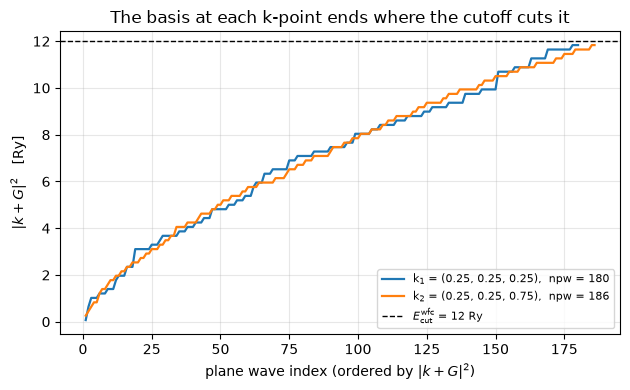

In [2]:
basis = calc.calculation.basis
gvectors, planewaves = basis.dense, basis.planewaves

print("dense grid : %d G-vectors, FFT dimensions %s" % (gvectors.ngm, gvectors.grid))
print("smooth grid: the same object (dual = %.1f, so no second grid)"
      % (system.ecutrho / system.ecutwfc))
print("plane waves per k-point: %s   padded to npwx = %d"
      % (tuple(planewaves.npw), planewaves.npwx))

kinetic = np.asarray(planewaves.kinetic(gvectors, kpoints, cell))
fig, ax = plt.subplots(figsize=(6.4, 4))
for ik in range(planewaves.nk):
    npw = planewaves.npw[ik]
    ax.plot(np.arange(1, npw + 1), kinetic[ik, :npw], lw=1.6,
            label=r"k$_%d$ = (%.2f, %.2f, %.2f),  npw = %d"
                  % (ik + 1, *np.asarray(kpoints.coords[ik]), npw))
ax.axhline(system.ecutwfc, color="k", ls="--", lw=1,
           label=r"$E_{\rm cut}^{\rm wfc}$ = %.0f Ry" % system.ecutwfc)
ax.set_xlabel("plane wave index (ordered by $|k+G|^2$)")
ax.set_ylabel(r"$|k+G|^2$   [Ry]")
ax.set_title("The basis at each k-point ends where the cutoff cuts it")
ax.legend(fontsize=8); ax.grid(alpha=0.3); fig.tight_layout()

## What that basis can represent

The structure factor $S(\mathbf G) = \sum_a e^{-i\mathbf G\cdot\tau_a}$ summed back over
the $\mathbf G$ inside the cutoff is a delta function at each atom, band-limited to the
basis. It is the sharpest object the basis holds, so the rings around each site are the
visual statement of what a finite cutoff costs: a plane-wave calculation can never
represent anything sharper than this.

S(G=0) = 2.0  (the number of atoms)


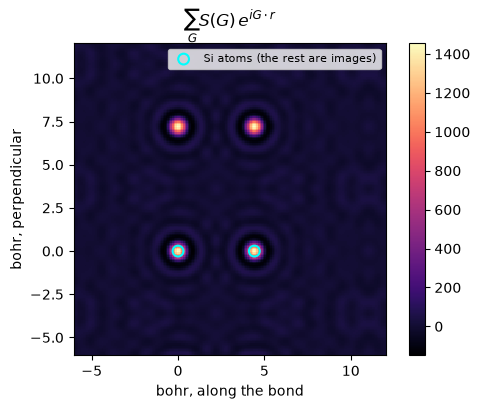

In [3]:
g_cart = np.asarray(gvectors.cartesian(cell))
tau = np.asarray(structure.positions)
structure_factor = np.exp(-1j * g_cart @ tau.T).sum(axis=1)

bond = tau[1] - tau[0]
e1 = bond / np.linalg.norm(bond)
e2 = np.cross(e1, [0.0, 0.0, 1.0]); e2 /= np.linalg.norm(e2)
span = np.linspace(-6.0, 12.0, 200)
u, v = np.meshgrid(span, span, indexing="ij")
plane = (tau[0] + u[..., None] * e1 + v[..., None] * e2).reshape(-1, 3)
image = (np.exp(1j * plane @ g_cart.T) * structure_factor).sum(axis=1).real.reshape(u.shape)

fig, ax = plt.subplots(figsize=(5.4, 4.2))
mesh = ax.pcolormesh(span, span, image.T, cmap="magma", shading="auto")
ax.scatter([0.0, np.linalg.norm(bond)], [0.0, 0.0], s=60, facecolors="none",
           edgecolors="cyan", lw=1.5, label="Si atoms (the rest are images)")
ax.set_aspect("equal"); ax.set_xlabel("bohr, along the bond")
ax.set_ylabel("bohr, perpendicular")
ax.set_title(r"$\sum_G S(G)\, e^{iG\cdot r}$")
ax.legend(fontsize=8, loc="upper right"); fig.colorbar(mesh, ax=ax); fig.tight_layout()

print("S(G=0) = %.1f  (the number of atoms)" % structure_factor[0].real)

## Against Quantum ESPRESSO

Every one of these numbers is printed in `pw.x`'s output header, which makes the geometry
checkable before a single energy is computed: the lattice vectors, the cell volume, the
number of reciprocal lattice vectors inside `ecutrho`, the FFT dimensions that hold them,
and the number of plane waves at each k-point.

In [4]:
reference = read_qe_output(Path("../tests/data/qe/reference.out.pw_scf-scf"))

rows = [
    ("lattice parameter (bohr)", "%.6f" % cell.alat, "%.6f" % reference.alat),
    ("cell volume (bohr^3)", "%.4f" % cell.volume, "%.4f" % reference.volume),
    ("G-vectors (dense)", gvectors.ngm, reference.ngm_dense),
    ("FFT dimensions", str(tuple(gvectors.grid)), str(tuple(reference.fft_dense))),
    ("plane waves per k-point", str(tuple(planewaves.npw)),
     str(tuple(int(n) for n in reference.npw))),
    ("k-points", kpoints.nk, len(reference.kpoints)),
]
print("%-28s %-18s %-18s" % ("quantity", "pypresso", "Quantum ESPRESSO"))
for name, ours, theirs in rows:
    print("%-28s %-18s %-18s %s" % (name, ours, theirs,
                                    "OK" if str(ours) == str(theirs) else "MISMATCH"))
print("\ncrystal axes match:    ",
      np.allclose(np.asarray(cell.at_alat), reference.at, atol=1e-6))
print("reciprocal axes match: ",
      np.allclose(np.asarray(cell.bg_2pi_alat), reference.bg, atol=1e-6))
print("k-points match:        ",
      np.allclose(np.asarray(kpoints.coords), reference.kpoints, atol=1e-6))

quantity                     pypresso           Quantum ESPRESSO  
lattice parameter (bohr)     10.200000          10.200000          OK
cell volume (bohr^3)         265.3020           265.3020           OK
G-vectors (dense)            1459               1459               OK
FFT dimensions               (16, 16, 16)       (16, 16, 16)       OK
plane waves per k-point      (180, 186)         (180, 186)         OK
k-points                     2                  2                  OK

crystal axes match:     True
reciprocal axes match:  True
k-points match:         True


---
The tests behind this notebook: `tests/regression/test_geometry.py`,
`tests/regression/test_basis.py`.